## Imports

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import ipaddress
import seaborn as sns

## Carregamento e limpeza do dataset

In [60]:
df = pd.read_csv('HIKARI.csv')
# eliminar elementos nulos
df = df.dropna()
# eliminar elementos duplicados
df = df.drop_duplicates()
# transformar o flow_duration para segundos
df["flow_duration"] = pd.to_timedelta(df["flow_duration"]).dt.total_seconds()
# eliminar as colunas uid
df = df.drop(columns=["uid", "attack_category"])
# converter valores para numéricos
for col in df.columns:
    if df[col].dtype == "object":
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass
# alterar IPs para números
df["originh"] = df["originh"].apply(lambda x: int(ipaddress.ip_address(x)))
df["responh"] = df["responh"].apply(lambda x: int(ipaddress.ip_address(x)))

## Separação do X e Y

In [61]:
# atribui o Y ao label
X = df.drop("Label", axis=1)
y = df["Label"]

# divisão de dataset de treino e de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=27, stratify=y)

# mostra os 5 valores iniciais
X.head()

,Unnamed: 0,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,bwd_last_window_size
0,0,3087020200,38164,3087020182,50443,0.000060,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,64240,0,64240,0
1,1,3087020201,43068,3087020182,50443,0.000083,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,64240,0,64240,0
2,2,3087020156,5678,4294967295,5678,119.996602,3,0,3,0,...,0.0,5.999748e+07,5.999912e+07,1.199966e+08,5.999830e+07,1156.846698,0,0,0,0
3,3,3087020156,5678,4294967295,5678,59.996909,2,0,2,0,...,0.0,5.999691e+07,5.999691e+07,5.999691e+07,5.999691e+07,0.000000,0,0,0,0
4,4,3087020156,5678,4294967295,5678,59.992130,2,0,2,0,...,0.0,5.999213e+07,5.999213e+07,5.999213e+07,5.999213e+07,0.000000,0,0,0,0


# Árvore de Decisão

In [62]:
# Cria um modelo de Árvore de Decisão
dt_classifier = DecisionTreeClassifier(random_state=1234)
dt_classifier = dt_classifier.fit(X_train, y_train)

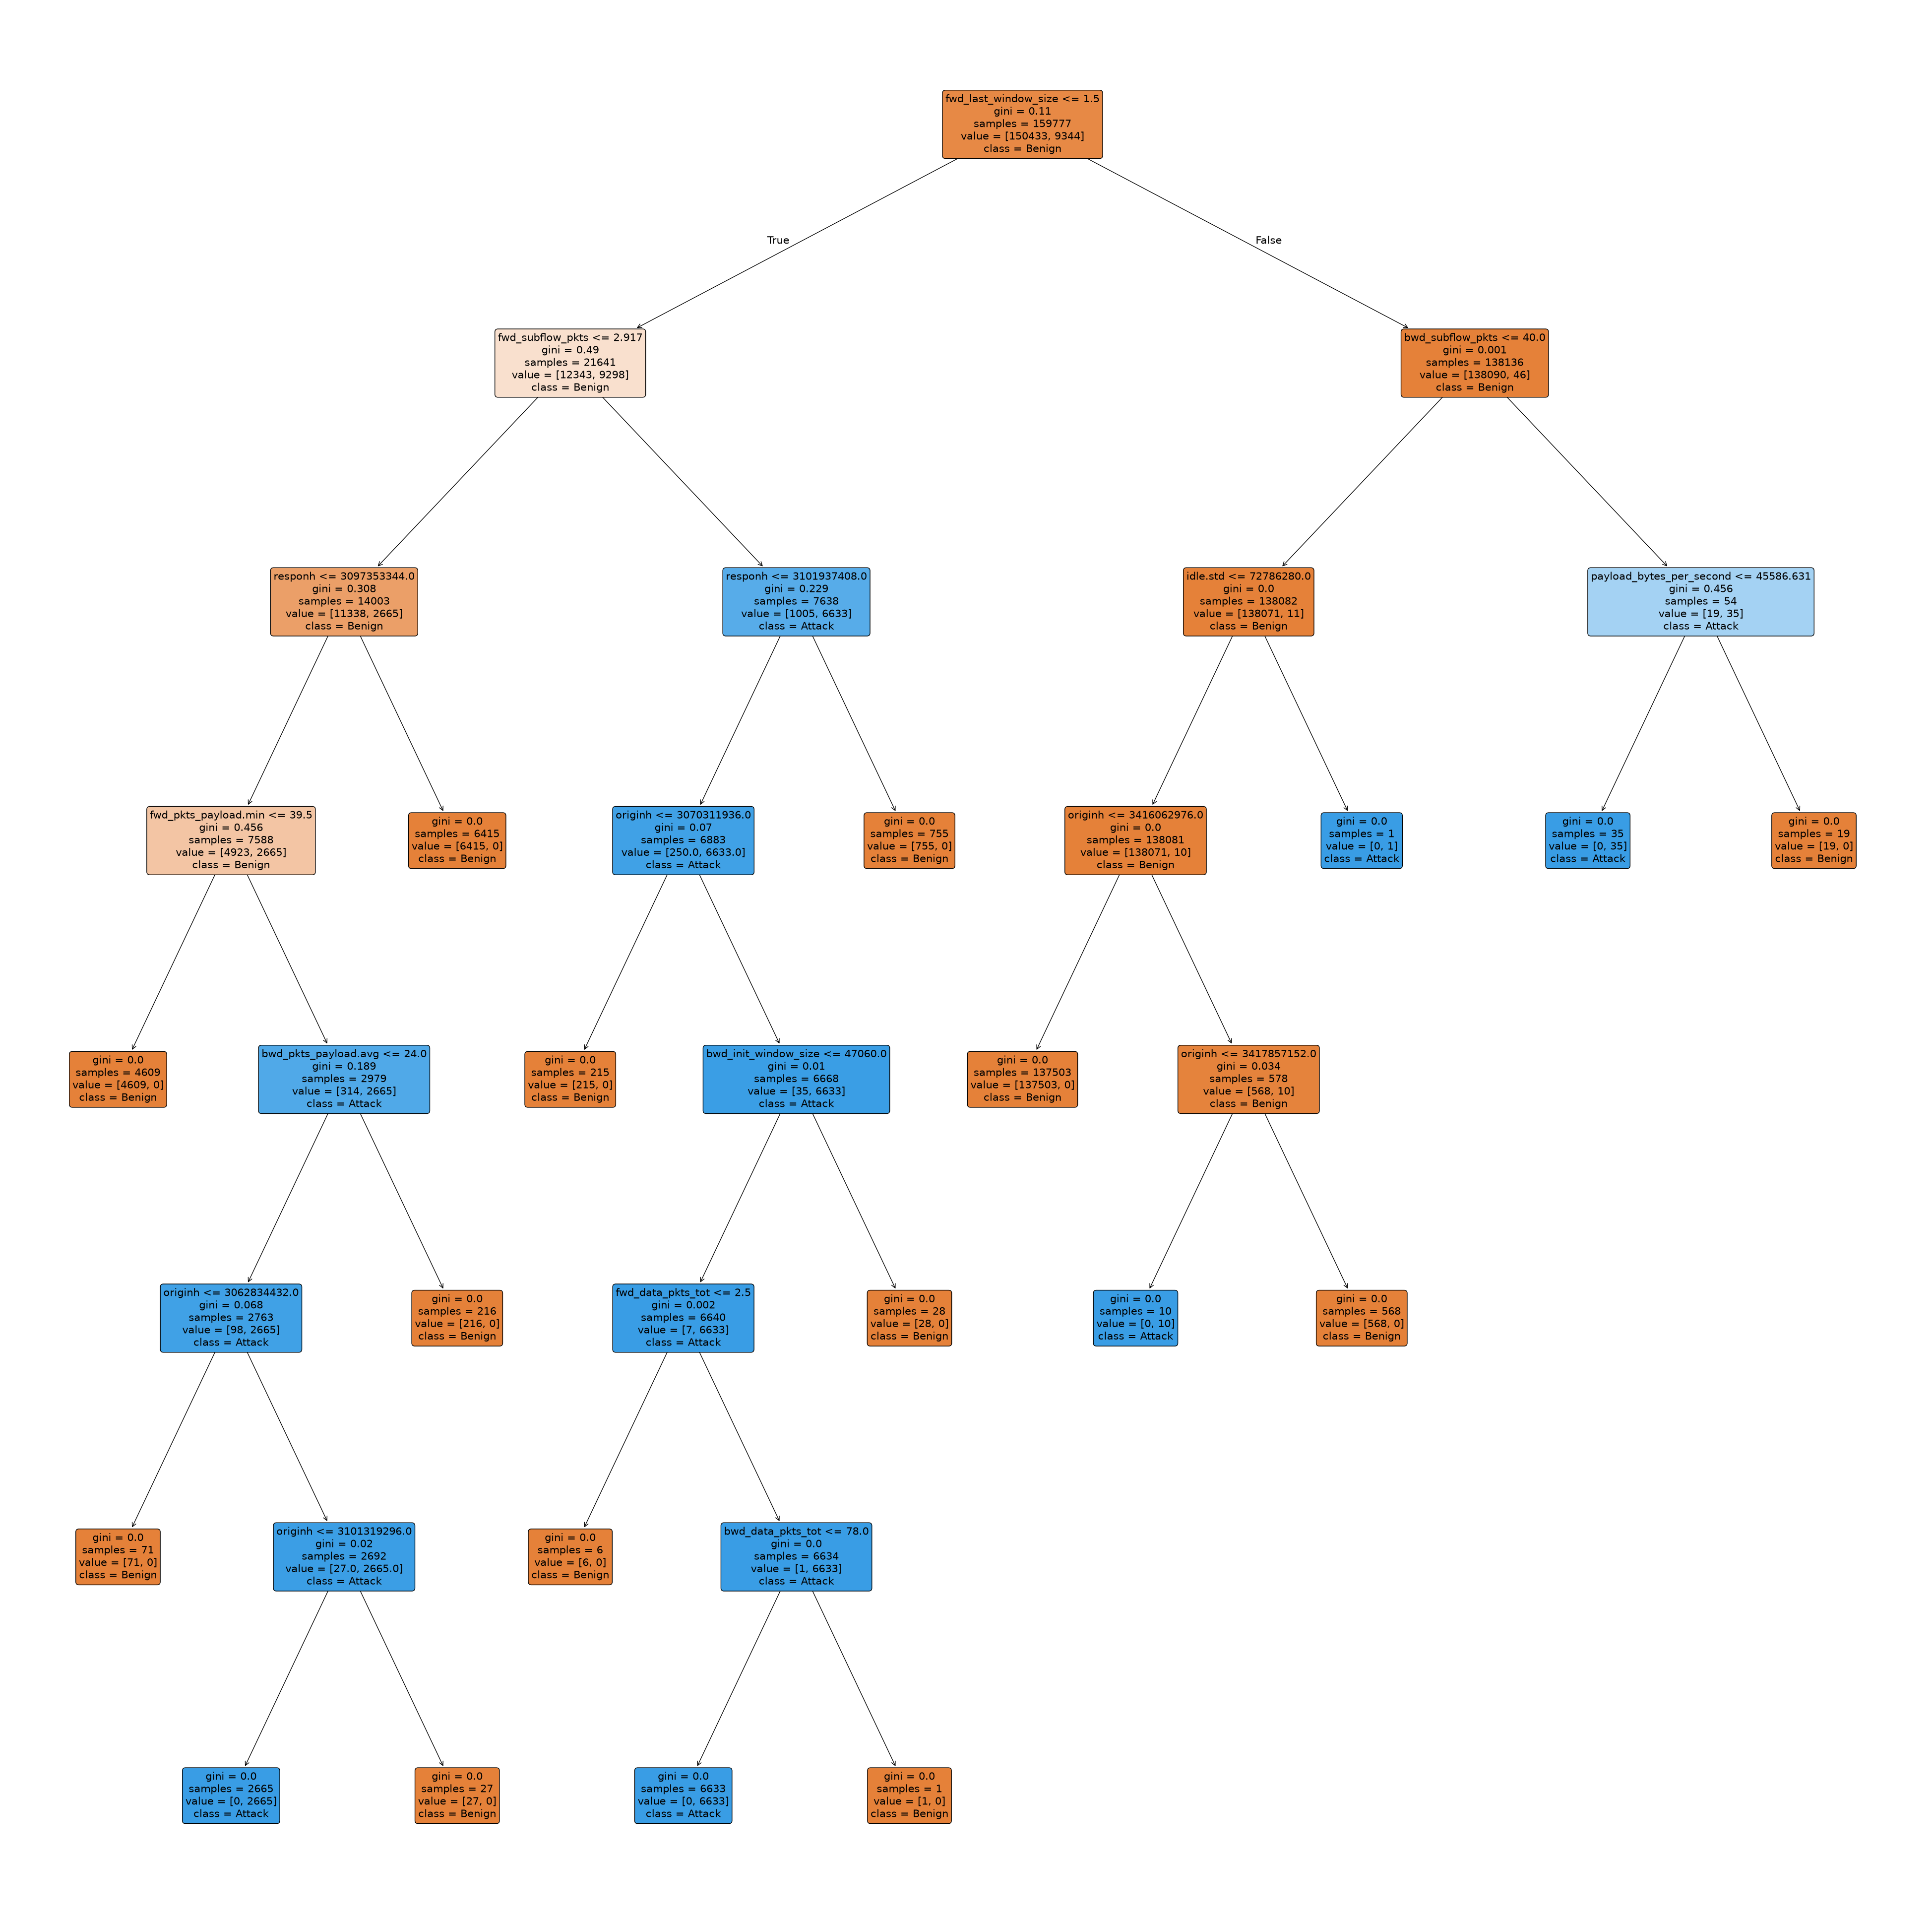

In [67]:
# Visualization of the tree model dt_classifier

plt.figure(figsize=(50,50))
tree.plot_tree(dt_classifier,
                   feature_names=X.columns,
                   class_names=["Benign", "Attack"],
                   filled=True, rounded=True)
plt.show()

### Avaliação do Modelo

In [64]:
# Avaliação do modelo com Classifier
y_pred = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9999707926864887


In [65]:
# Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     64471
           1       1.00      1.00      1.00      4005

    accuracy                           1.00     68476
   macro avg       1.00      1.00      1.00     68476
weighted avg       1.00      1.00      1.00     68476



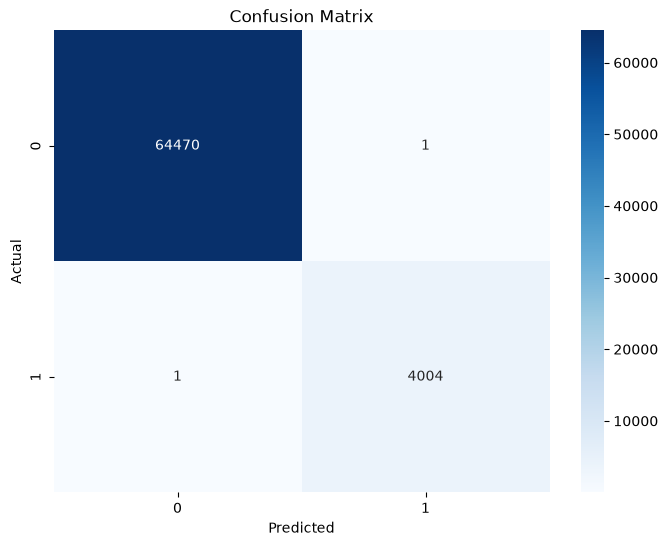

In [66]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()